# 03 · Personalized anomaly detection

Does a night differ from the same person's earlier nights? The detector was fixed in
`docs/decisions.md` (41–45) and committed before any run.

- **Baseline.** Expected heart rate and movement for each person, sleep stage and time of night,
  built from that person's earlier nights and shrunk toward a population prior. With few nights,
  a person looks like the population.
- **Night channels**, all in the "worse sleep" direction:
  - the highest 30-min heart-rate z;
  - the whole-night heart-rate z;
  - wake bouts per hour;
  - onset latency.
- **Alarm.** A night is flagged when its smallest channel tail probability falls under a
  threshold. The threshold is set on *other people's* clean nights, scored out of sample, for
  at most 5% false alarms.
- **Validation.** Anomalies are injected into the raw signals of test nights at known times and
  sizes, then pushed through the same feature, staging and scoring code.
- **Primary detector:** stages predicted by the population GRU (what a real user would have),
  with the personal baseline. Expert stages are the best case, and "none" is a stage-free
  detector. Each also runs with a population-only baseline.

Nothing in this notebook is fitted or tuned; it only reads the saved run. There are no causal
claims: a flag means "different from this person's earlier nights", not why.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sleepwatch.anomaly import baseline as bl
from sleepwatch.anomaly import scores as sc
from sleepwatch.anomaly.experiment import AnomalyConfig, _inputs
from sleepwatch.config import get_settings
from sleepwatch.constants import EPOCH_S
from sleepwatch.features.build import load_build
from sleepwatch.models.data import prepare
from sleepwatch.models.splits import load_folds

settings = get_settings()
index = pd.read_csv(settings.results_dir / "anomaly_index.csv")
latest = index[(index["name"] == "anomaly_main") & ~index["partial"]].iloc[-1]
run_dir = settings.results_dir / latest["name"] / latest["run"]
info = json.loads((run_dir / "run.json").read_text())
cfg = AnomalyConfig.model_validate(
    __import__("yaml").safe_load((run_dir / "config.yaml").read_text())
)
metrics = json.loads((run_dir / "metrics.json").read_text())
scores = pd.read_parquet(run_dir / "night_scores.parquet")
for column in ["window", "bouts", "window_stages"]:
    scores[column] = scores[column].map(lambda v: json.loads(v) if isinstance(v, str) else None)
truth = pd.read_parquet(run_dir / "injections.parquet")
truth["windows"] = truth["windows"].map(json.loads)
epochs_run = pd.read_parquet(run_dir / "epochs.parquet")
stages = pd.read_parquet(run_dir / "stages.parquet")
nights = pd.read_parquet(run_dir / "nights.parquet")
flagged = json.loads((run_dir / "flagged_nights.json").read_text())
print(f"run {latest['run']} at commit {info['git']['commit'][:8]}; dirty: {info['git']['dirty']}")
assert not info["git"]["dirty"] and not latest["partial"]
print("integrity checks:", info["checks"])
assert (
    info["checks"]["features_equal"] == info["checks"]["stages_equal"] == info["checks"]["nights"]
)
primary = scores[(scores["source"] == "gru") & (scores["baseline"] == "personal")]
tested = primary[primary["version"] == "clean"]
print(
    f"{int(nights['scored'].sum())} scored nights ({len(tested)} as test nights), "
    f"{nights['subject'].nunique()} subjects; excluded: {cfg.exclude}"
)
per_night = truth.groupby(["subject", "night"]).size()
skipped = sorted(
    set(map(tuple, tested[["subject", "night"]].to_numpy()))
    - set(map(tuple, truth.query("kind != 'hr'")[["subject", "night"]].to_numpy()))
)
print(
    f"injected versions per night: {per_night.min()}-{per_night.max()} "
    f"({len(truth)} in total); nights without a wake stretch to copy: {skipped}"
)

COLORS = {
    "gru": "#2a78d6",
    "expert": "#eb6834",
    "none": "#a9a8a3",
    "hr": "#2a78d6",
    "frag": "#eb6834",
    "onset": "#7e57c2",
}
plt.rcParams.update(
    {
        "figure.facecolor": "#fcfcfb",
        "axes.facecolor": "#fcfcfb",
        "axes.edgecolor": "#a9a8a3",
        "axes.labelcolor": "#52514e",
        "xtick.color": "#52514e",
        "ytick.color": "#52514e",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e1",
        "grid.linewidth": 0.6,
        "lines.linewidth": 1.2,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "font.size": 9,
        "legend.frameon": False,
    }
)


def ci(value, bounds, digits=2):
    return f"{value:.{digits}f} [{bounds[0]:.{digits}f}, {bounds[1]:.{digits}f}]"

run 20261006T091359Z at commit 93c9a177; dirty: False
integrity checks: {'nights': 157, 'features_equal': 157, 'stages_equal': 157}
157 scored nights (157 as test nights), 47 subjects; excluded: [('Bidslab42', 1), ('Bidslab68', 2)]
injected versions per night: 9-15 (2337 in total); nights without a wake stretch to copy: [('Bidslab31', 3), ('Bidslab31', 5), ('Bidslab45', 3)]


## 1 · What the detector sees

Each panel shows a night's heart rate against the personal expectation (±1 SD band) and the
predicted hypnogram. The expectation is recomputed here with the library functions, from the
saved stages and the stored epoch table, and checked against the saved channel values. The
first panel is a clean test night with a typical score; the others are injected versions of the
same night (shaded: where the anomaly was put).

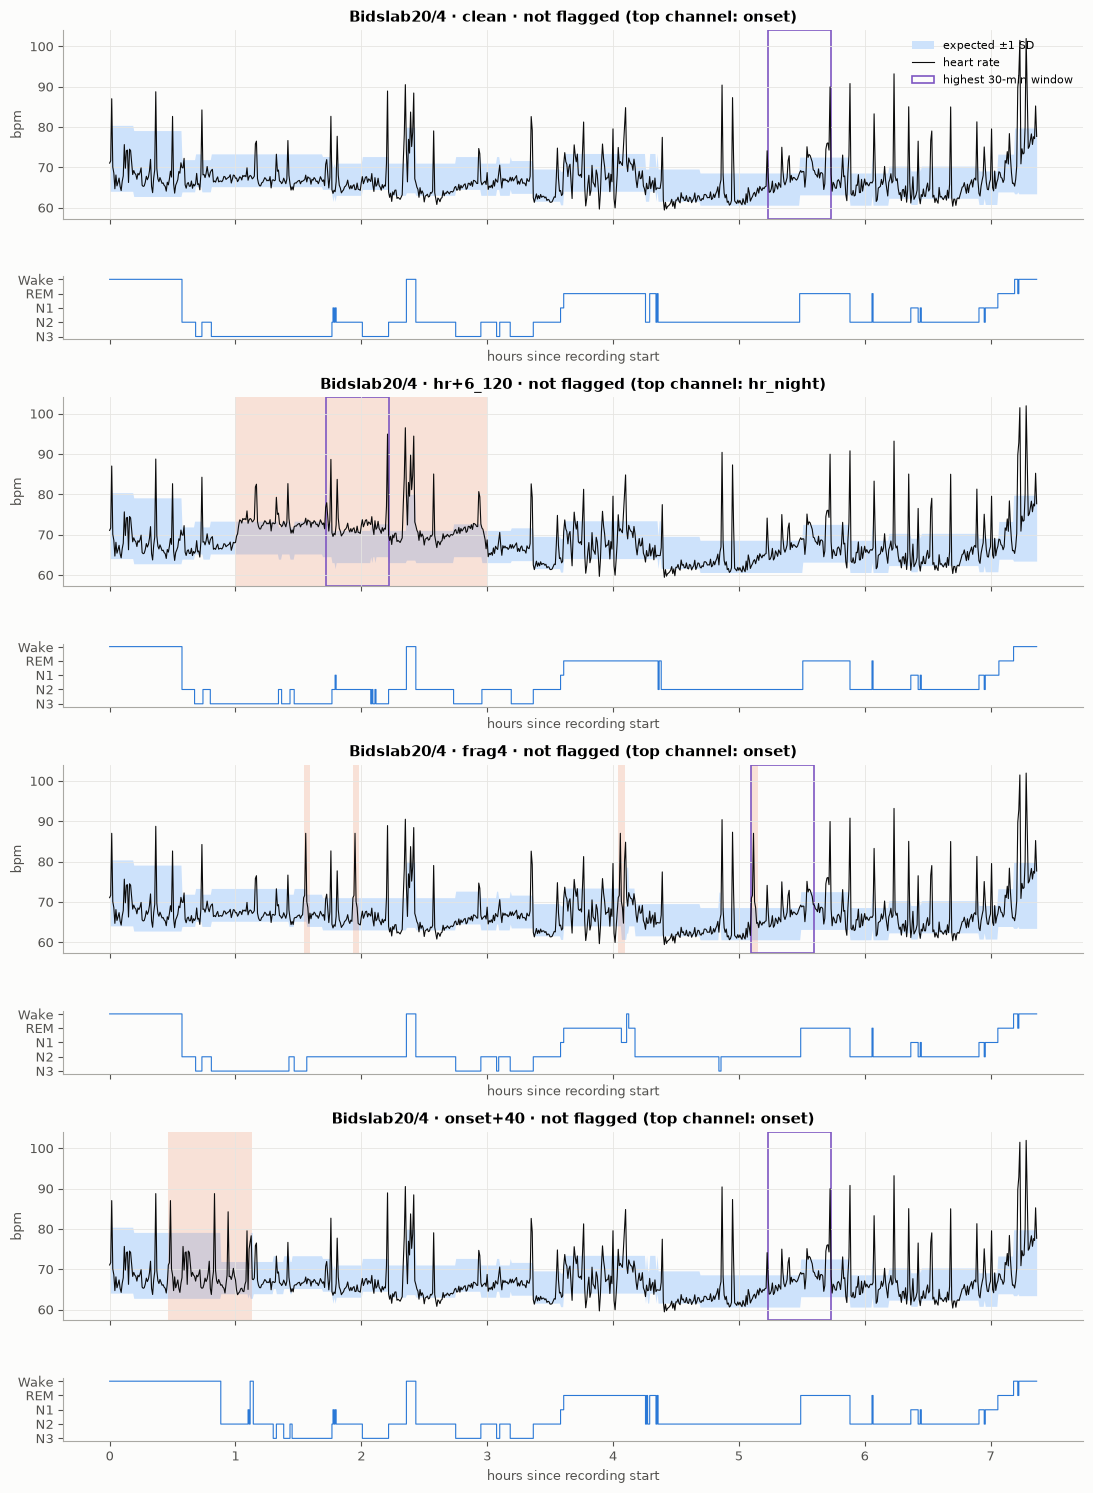

In [2]:
epochs, quality, _ = load_build(cfg.features, settings.processed_dir)
data = prepare(epochs)
folds = load_folds()
usable = nights[nights["usable"]]
rank = nights.set_index(["subject", "night"])


def detector_view(subject, night, version):
    """Inputs, expected HR and z for one night version, as the primary detector saw it."""
    fold = folds[subject]
    st = stages[stages["fold"] == fold]
    keys = ["subject", "night", "epoch"]
    clean = data.merge(usable[["subject", "night"]], on=["subject", "night"])
    train = clean.merge(st[st["role"] == "train"][[*keys, "gru"]], on=keys)
    prior = bl.fit_prior(_inputs(train, "gru"))
    mine = clean[clean["subject"] == subject].merge(
        st[st["role"] == "test"][[*keys, "gru"]], on=keys
    )
    history = _inputs(mine, "gru")
    this = rank.loc[(subject, night), "night_rank"]
    earlier = [
        (subject, n)
        for (s, n), r in rank.iterrows()
        if s == subject and r["usable"] and r["night_rank"] < this
    ]
    offsets = bl.personal_offsets(bl.night_summaries(history, prior).loc[earlier], prior)
    target = epochs_run[
        (epochs_run["subject"] == subject)
        & (epochs_run["night"] == night)
        & (epochs_run["version"] == version)
    ].sort_values("epoch")
    view = _inputs(target.reset_index(drop=True), "gru")
    view = view.join(bl.score_epochs(view, prior, offsets))
    view["sd_hr"] = prior.sd(view, "hr")
    population = bl.score_epochs(view, prior, None)
    ch = sc.night_channels(view.assign(z_act_pop=population["z_act"]), True, cfg.channels)
    saved = primary[
        (primary["subject"] == subject)
        & (primary["night"] == night)
        & (primary["version"] == version)
    ].iloc[0]
    assert np.isclose(ch["hr_window"], saved["hr_window"], equal_nan=True), "recomputation differs"
    assert np.isclose(ch["hr_night"], saved["hr_night"], equal_nan=True)
    return view, saved


def plot_night(ax_hr, ax_stage, view, title, shade=(), flag=None):
    hours = view["epoch"] * EPOCH_S / 3600
    ax_hr.fill_between(
        hours,
        view["expected_hr"] - view["sd_hr"],
        view["expected_hr"] + view["sd_hr"],
        color="#cde2fb",
        lw=0,
        label="expected ±1 SD",
    )
    ax_hr.plot(hours, view["hr"], color="#0b0b0b", lw=0.8, label="heart rate")
    for a, b in shade:
        ax_hr.axvspan(a * EPOCH_S / 3600, b * EPOCH_S / 3600, color="#eb6834", alpha=0.18, lw=0)
    if flag is not None:
        ax_hr.axvspan(
            flag[0] * EPOCH_S / 3600,
            flag[1] * EPOCH_S / 3600,
            fill=False,
            ec="#7e57c2",
            lw=1.2,
            label="highest 30-min window",
        )
    ax_hr.set(title=title, ylabel="bpm")
    ax_stage.step(
        hours,
        view["stage"].map({0: 4, 4: 3, 1: 2, 2: 1, 3: 0}),
        where="post",
        color="#2a78d6",
        lw=0.8,
    )
    ax_stage.set_yticks([0, 1, 2, 3, 4], ["N3", "N2", "N1", "REM", "Wake"])
    ax_stage.set(xlabel="hours since recording start")
    ax_stage.grid(False)


typical = tested.iloc[(tested["hr_night"] - tested["hr_night"].median()).abs().argsort()].iloc[0]
subject, night = typical["subject"], int(typical["night"])
examples = ["clean", "hr+6_120", "frag4", "onset+40"]
fig, axes = plt.subplots(
    8, 1, figsize=(11, 15), gridspec_kw={"height_ratios": [3, 1] * 4}, sharex=True
)
for i, version in enumerate(examples):
    if version not in set(epochs_run.query("subject == @subject and night == @night")["version"]):
        continue
    view, saved = detector_view(subject, night, version)
    shade = []
    if version != "clean":
        shade = truth.query("subject == @subject and night == @night and version == @version")[
            "windows"
        ].iloc[0]
    flag_text = "flagged" if saved["flagged"] else "not flagged"
    plot_night(
        axes[2 * i],
        axes[2 * i + 1],
        view,
        f"{subject}/{night} · {version} · {flag_text} (top channel: {saved['top_channel']})",
        shade,
        saved["window"],
    )
axes[0].legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

## 2 · False alarms

The alarm threshold was set on training subjects' clean nights so that at most 5% would be
flagged. The question is whether that carries over to **new people**: the false-alarm rate on
the clean test nights. A rate well above 5% would mean the calibration doesn't transfer.

In [3]:
rows = []
for name, entry in metrics["variants"].items():
    fa = entry["false_alarm_rate"]
    source, variant = name.split("/")
    part = scores[(scores["source"] == source) & (scores["baseline"] == variant)]
    rows.append(
        {
            "stages": source,
            "baseline": variant,
            "false-alarm rate on clean test nights [95% CI]": ci(fa["value"], fa["ci95"], 3),
            "clean test nights": fa["nights"],
            "null rate on training subjects (by fold)": ", ".join(
                f"{r:.3f}" for r in part.groupby("fold")["null_rate"].first()
            ),
        }
    )
display(pd.DataFrame(rows))

,stages,baseline,false-alarm rate on clean test nights [95% CI],clean test nights,null rate on training subjects (by fold)
0,expert,personal,"0.032 [0.006, 0.063]",157,"0.033, 0.032, 0.048, 0.031, 0.031"
1,expert,population,"0.032 [0.000, 0.082]",157,"0.033, 0.032, 0.048, 0.031, 0.031"
2,gru,personal,"0.032 [0.007, 0.061]",157,"0.025, 0.048, 0.048, 0.031, 0.031"
3,gru,population,"0.025 [0.000, 0.075]",157,"0.025, 0.032, 0.048, 0.031, 0.047"
4,none,personal,"0.045 [0.018, 0.076]",157,"0.033, 0.040, 0.040, 0.039, 0.039"
5,none,population,"0.045 [0.011, 0.094]",157,"0.033, 0.040, 0.040, 0.039, 0.039"


## 3 · Detection of injected anomalies (primary detector)

- **Recall:** the share of injected nights flagged at the calibrated threshold.
- **AUROC:** how well the continuous score separates injected nights from clean test nights,
  regardless of threshold.
- **Precision:** derived for an *assumed* 10% of nights being anomalous, from recall and the
  observed false-alarm rate.
- **Localized:** for 30-min and 2-h HR injections, the share of flagged nights whose highest
  window is centred inside the injected window.
- **Awakenings seen:** the share of inserted awakenings that overlap a wake bout in the predicted
  stages.
- **Right channel:** the share of flagged nights whose smallest tail probability is in the
  channel matching the injected type.

95% CIs resample subjects.

,version,kind,size,duration (min),nights,recall [95% CI],AUROC [95% CI],precision @10%,localized,awakenings seen,right channel
0,hr+3_30,hr,3.0,30.0,157,"0.03 [0.01, 0.06]","0.50 [0.50, 0.51]",0.10,0.20,NaN,0.80
1,hr+3_120,hr,3.0,120.0,157,"0.04 [0.01, 0.08]","0.53 [0.52, 0.54]",0.13,0.14,NaN,0.71
2,hr+3_sleep,hr,3.0,0.0,157,"0.04 [0.01, 0.08]","0.60 [0.58, 0.62]",0.13,NaN,NaN,0.86
3,hr+6_30,hr,6.0,30.0,157,"0.03 [0.01, 0.05]","0.52 [0.51, 0.54]",0.08,0.75,NaN,0.75
4,hr+6_120,hr,6.0,120.0,157,"0.04 [0.01, 0.08]","0.58 [0.56, 0.61]",0.12,0.67,NaN,0.83
5,hr+6_sleep,hr,6.0,0.0,157,"0.08 [0.03, 0.14]","0.70 [0.67, 0.74]",0.22,NaN,NaN,0.92
6,hr+10_30,hr,10.0,30.0,157,"0.04 [0.01, 0.08]","0.58 [0.56, 0.61]",0.13,0.29,NaN,0.71
7,hr+10_120,hr,10.0,120.0,157,"0.08 [0.04, 0.14]","0.69 [0.65, 0.74]",0.22,0.92,NaN,0.92
8,hr+10_sleep,hr,10.0,0.0,157,"0.27 [0.18, 0.37]","0.82 [0.78, 0.87]",0.49,NaN,NaN,0.93
9,frag2,frag,2.0,NaN,154,"0.04 [0.01, 0.07]","0.58 [0.56, 0.60]",0.12,NaN,0.57,0.17


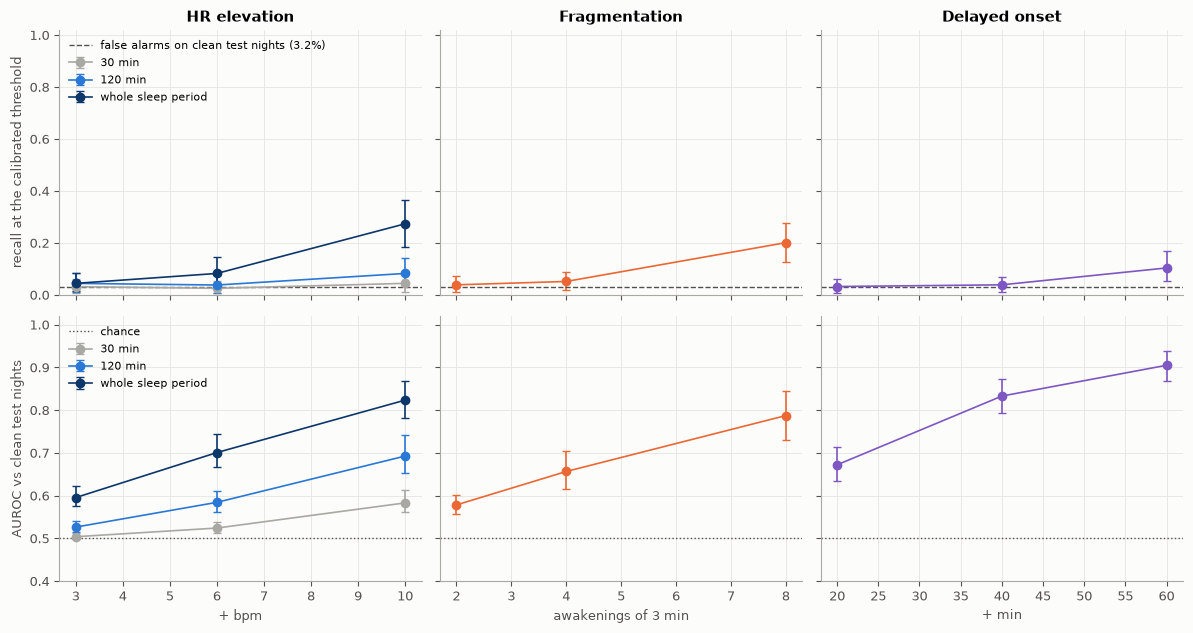

In [4]:
def condition_table(name):
    rows = []
    for version, c in metrics["variants"][name]["conditions"].items():
        rows.append(
            {
                "version": version,
                "kind": c["kind"],
                "size": c["size"],
                "duration (min)": c["duration_min"],
                "nights": c["nights"],
                "recall [95% CI]": ci(c["recall"], c["recall_ci95"]),
                "AUROC [95% CI]": ci(c["auroc"], c["auroc_ci95"]),
                "precision @10%": round(c["precision_at_prevalence"], 2),
                "localized": round(c["localized"], 2) if "localized" in c else None,
                "awakenings seen": round(c["awakenings_seen"], 2)
                if "awakenings_seen" in c
                else None,
                "right channel": round(c["type_correct"], 2)
                if c["type_correct"] == c["type_correct"]
                else None,
                "_recall": c["recall"],
                "_low": c["recall_ci95"][0],
                "_high": c["recall_ci95"][1],
                "_auroc": c["auroc"],
                "_auroc_low": c["auroc_ci95"][0],
                "_auroc_high": c["auroc_ci95"][1],
            }
        )
    return pd.DataFrame(rows)


table = condition_table("gru/personal")
display(table.drop(columns=[c for c in table.columns if c.startswith("_")]))

fig, axes = plt.subplots(2, 3, figsize=(12, 6.4), sharey="row", sharex="col")
false_alarm = metrics["variants"]["gru/personal"]["false_alarm_rate"]["value"]
panels = [
    ("hr", "HR elevation", "+ bpm"),
    ("frag", "Fragmentation", "awakenings of 3 min"),
    ("onset", "Delayed onset", "+ min"),
]
for row, (value, low, high) in enumerate(
    [("_recall", "_low", "_high"), ("_auroc", "_auroc_low", "_auroc_high")]
):
    for col, (kind, title, xlabel) in enumerate(panels):
        ax = axes[row, col]
        part = table[table["kind"] == kind]
        groups = (
            [(30, "#a9a8a3"), (120, "#2a78d6"), (0, "#0d366b")] if kind == "hr" else [(None, None)]
        )
        for duration, color in groups:
            sub = part if duration is None else part[part["duration (min)"] == duration]
            sub = sub.sort_values("size")
            ax.errorbar(
                sub["size"],
                sub[value],
                yerr=[sub[value] - sub[low], sub[high] - sub[value]],
                marker="o",
                capsize=3,
                color=color or COLORS[kind],
                label=None
                if duration is None
                else ("whole sleep period" if duration == 0 else f"{duration} min"),
            )
        if row == 0:
            ax.axhline(
                false_alarm,
                color="#52514e",
                lw=1,
                ls="--",
                label=f"false alarms on clean test nights ({false_alarm:.1%})"
                if col == 0
                else None,
            )
            ax.set(title=title, ylim=(0, 1.02))
        else:
            ax.axhline(0.5, color="#52514e", lw=1, ls=":", label="chance" if col == 0 else None)
            ax.set(xlabel=xlabel, ylim=(0.4, 1.02))
axes[0, 0].set_ylabel("recall at the calibrated threshold")
axes[1, 0].set_ylabel("AUROC vs clean test nights")
axes[0, 0].legend(fontsize=8, loc="upper left")
axes[1, 0].legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## 4 · What the personal baseline and the stages add

Recall per condition for all six detectors, then the paired recall differences of the primary
detector against three alternatives: a population-only baseline, expert stages and no stages.
The baseline comparison is the direct test of personalization in Phase 3.

In [5]:
recall = pd.DataFrame(
    {
        name: {v: c["recall"] for v, c in entry["conditions"].items()}
        for name, entry in metrics["variants"].items()
    }
)
display(recall.round(2))
diffs = []
for label, comparison in metrics["comparisons"].items():
    for version, d in comparison.items():
        diffs.append(
            {
                "comparison": label,
                "version": version,
                "recall difference [95% CI]": ci(d["recall_difference"], d["ci95"]),
            }
        )
display(
    pd.DataFrame(diffs).pivot(
        index="version", columns="comparison", values="recall difference [95% CI]"
    )
)

,expert/personal,expert/population,gru/personal,gru/population,none/personal,none/population
hr+3_30,0.03,0.03,0.03,0.03,0.04,0.04
hr+3_120,0.03,0.03,0.04,0.03,0.05,0.04
hr+3_sleep,0.04,0.03,0.04,0.03,0.06,0.04
hr+6_30,0.03,0.03,0.03,0.03,0.04,0.04
hr+6_120,0.04,0.03,0.04,0.03,0.05,0.04
hr+6_sleep,0.08,0.04,0.08,0.06,0.13,0.07
hr+10_30,0.03,0.03,0.04,0.03,0.06,0.05
hr+10_120,0.06,0.04,0.08,0.06,0.09,0.05
hr+10_sleep,0.23,0.09,0.27,0.10,0.36,0.10
frag2,0.09,0.10,0.04,0.04,0.05,0.05


comparison,gru/personal minus expert/personal,gru/personal minus gru/population,gru/personal minus none/personal
version,,,
frag2,"-0.05 [-0.10, -0.01]","0.00 [-0.05, 0.04]","-0.01 [-0.03, 0.02]"
frag4,"-0.13 [-0.18, -0.07]","-0.01 [-0.05, 0.02]","-0.01 [-0.05, 0.04]"
frag8,"-0.43 [-0.53, -0.33]","-0.02 [-0.08, 0.04]","0.08 [0.00, 0.16]"
hr+10_120,"0.03 [-0.02, 0.08]","0.03 [0.01, 0.05]","-0.01 [-0.06, 0.05]"
hr+10_30,"0.01 [-0.01, 0.04]","0.01 [-0.01, 0.04]","-0.01 [-0.04, 0.01]"
hr+10_sleep,"0.04 [-0.00, 0.09]","0.17 [0.11, 0.24]","-0.09 [-0.15, -0.03]"
hr+3_120,"0.01 [-0.02, 0.04]","0.01 [-0.01, 0.04]","-0.01 [-0.03, 0.02]"
hr+3_30,"0.00 [-0.03, 0.02]","0.01 [-0.03, 0.04]","-0.01 [-0.04, 0.01]"
hr+3_sleep,"0.00 [-0.03, 0.03]","0.01 [-0.01, 0.04]","-0.01 [-0.04, 0.01]"


## 5 · Does a longer baseline help?

Recall of the primary detector by the number of earlier nights the baseline had. Descriptive
only: the groups contain different people.

In [6]:
by_n = pd.DataFrame({k: v["recall"] for k, v in metrics["by_baseline_nights"].items()})
by_n.loc["false-alarm rate"] = [
    v["false_alarm_rate"] for v in metrics["by_baseline_nights"].values()
]
by_n.loc["nights"] = [v["nights"] for v in metrics["by_baseline_nights"].values()]
display(by_n.round(2))

,2,3,4+
frag2,0.07,0.00,0.04
frag4,0.07,0.05,0.04
frag8,0.24,0.19,0.18
hr+10_120,0.11,0.05,0.09
hr+10_30,0.06,0.00,0.06
hr+10_sleep,0.23,0.29,0.29
hr+3_120,0.06,0.05,0.03
hr+3_30,0.06,0.00,0.03
hr+3_sleep,0.06,0.02,0.04
hr+6_120,0.06,0.02,0.03


## 6 · Real nights the detector flags

These are clean test nights flagged by the primary detector. Up to 5% of nights are expected to
be flagged by chance alone (the training null rates were 2.5–4.8%), so a flag is a prompt to
look, not a finding. The table gives the
structured summary passed to the Phase 4 agent; the plots show where the night departs from the
personal expectation. Known data problems are listed where they apply. **No causes are
inferred.**

5 of 157 clean test nights flagged (at the nominal 5%, about 8 would be expected by chance)


,night,date,baseline nights,top channel,fired,window,HR above expected (bpm),window stages,wake bouts/h,onset (min),data quality
0,Bidslab11/3,2022-03-28,2,hr_night,"hr_window, hr_night",23:04-23:34,19.9,N3 100%,0.1,18,
1,Bidslab22/6,2022-03-05,5,hr_window,"hr_window, hr_night",02:34-03:04,17.8,"N2 17%, N3 57%, REM 27%",0.2,14,
2,Bidslab43/3,2021-08-28,2,hr_window,hr_window,00:29-00:59,34.5,"Wake 82%, N2 13%, N3 5%",0.4,62,
3,Bidslab66/3,2022-09-06,2,hr_night,hr_night,00:23-00:53,18.5,N3 100%,0.3,28,
4,Bidslab32/6,2021-11-05,5,onset,onset,04:15-04:45,9.3,"Wake 8%, N2 52%, N3 40%",0.5,108,


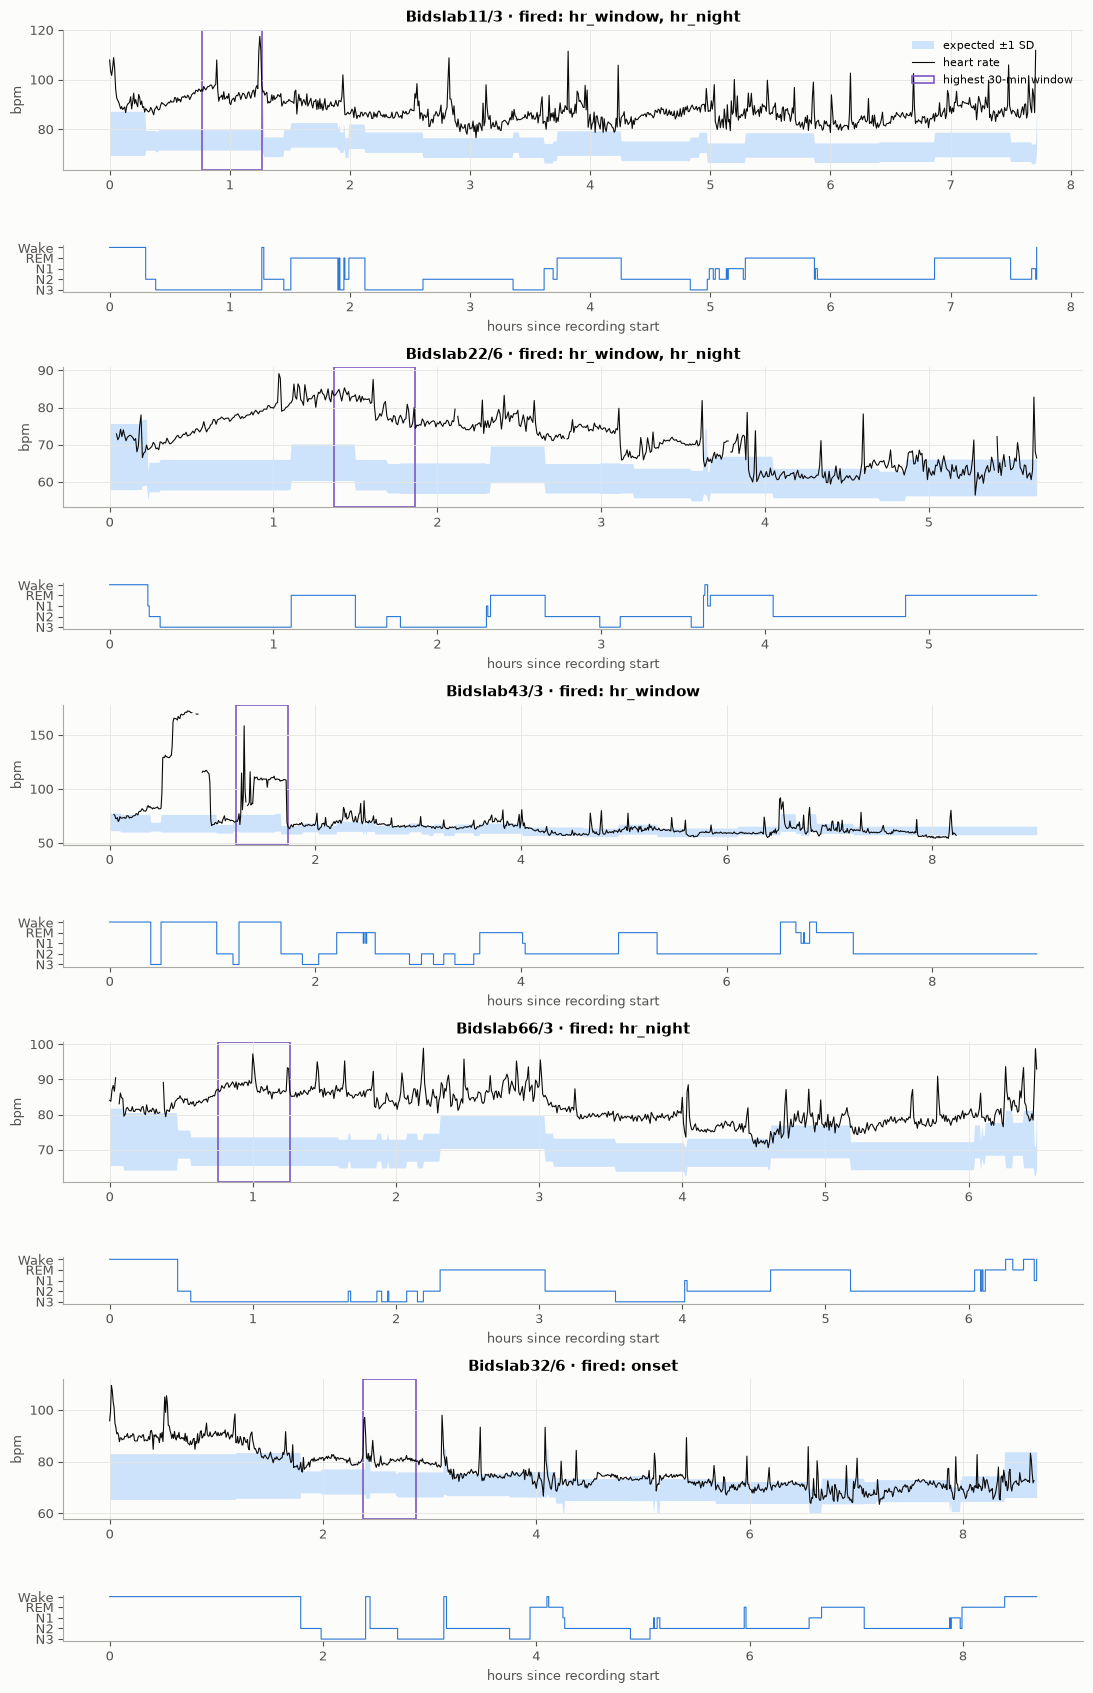

In [7]:
print(
    f"{len(flagged)} of {len(tested)} clean test nights flagged "
    f"(at the nominal 5%, about {0.05 * len(tested):.0f} would be expected by chance)"
)
summary = pd.DataFrame(
    [
        {
            "night": f"{f['subject']}/{f['night']}",
            "date": f["date_local"],
            "baseline nights": f["baseline_nights"],
            "top channel": f["top_channel"],
            "fired": ", ".join(c["channel"] for c in f["channels"] if c["fired"]),
            "window": "-".join(
                (f[k] or "")[11:] for k in ("window_start_local", "window_end_local")
            ),
            "HR above expected (bpm)": (
                None if f["hr_excess_bpm"] is None else round(f["hr_excess_bpm"], 1)
            ),
            "window stages": ", ".join(f"{k} {v:.0%}" for k, v in f["window_stage_share"].items()),
            "wake bouts/h": None
            if f["wake_bouts_per_hour"] is None
            else round(f["wake_bouts_per_hour"], 1),
            "onset (min)": None
            if f["onset_latency_min"] is None
            else round(f["onset_latency_min"]),
            "data quality": "; ".join(f["data_quality"]),
        }
        for f in flagged
    ]
)
display(summary)
shown = flagged[:6]
if shown:
    fig, axes = plt.subplots(
        2 * len(shown),
        1,
        figsize=(11, 3.4 * len(shown)),
        gridspec_kw={"height_ratios": [3, 1] * len(shown)},
    )
    for i, f in enumerate(shown):
        view, saved = detector_view(f["subject"], f["night"], "clean")
        plot_night(
            axes[2 * i],
            axes[2 * i + 1],
            view,
            f"{f['subject']}/{f['night']} · fired: "
            + ", ".join(c["channel"] for c in f["channels"] if c["fired"]),
            flag=saved["window"],
        )
    axes[0].legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()

## 7 · Why recall is low (post-hoc diagnostics)

**Written after seeing the results above.** These cells explain the numbers. They change nothing:
no threshold, channel or setting was chosen from them, and the pre-declared metrics above stand.

1. **How strict the threshold is.** The rule picks the largest threshold whose leave-one-out
   rate on the ~125 training nights is at most 5%. Tail probabilities move in steps of
   1/(n+1), and the night score is the smallest of four channels. So the next step up usually
   overshoots 5%, and the threshold lands at the very edge of the training nights. The table
   gives *k*: a test night is flagged only if, in at least one channel, it beats all but *k* of
   the *n* training nights.
2. **How far the largest injections move each channel**, compared with the spread of the
   training nights (primary detector, z units). The shift is paired: injected minus clean
   version of the same night.
3. **Which training nights set the edge.** These are the most extreme training nights per
   channel. Because of point 1, they decide what can be flagged.

In [8]:
calib = scores.groupby(["source", "baseline", "fold"])[["threshold", "null_nights"]].first()
calib["k"] = np.floor(calib["threshold"] * (calib["null_nights"] + 1) + 1e-9).astype(int) - 1
calib["beat all but k of n"] = [
    f"{k} of {n}" for k, n in zip(calib["k"], calib["null_nights"], strict=True)
]
display(calib["beat all but k of n"].unstack("fold"))

fold                      0         1         2         3         4
source baseline                                                    
expert personal    0 of 120  0 of 124  1 of 126  0 of 129  0 of 129
       population  0 of 120  0 of 124  1 of 126  0 of 129  0 of 129
gru    personal    0 of 120  1 of 124  1 of 126  0 of 129  0 of 129
       population  0 of 120  0 of 124  1 of 126  0 of 129  1 of 129
none   personal    0 of 120  1 of 124  1 of 126  1 of 129  1 of 129
       population  0 of 120  1 of 124  1 of 126  1 of 129  1 of 129

In [9]:
null = pd.read_parquet(run_dir / "null_scores.parquet")
null_primary = null[(null["source"] == "gru") & (null["baseline"] == "personal")]
keys = ["subject", "night"]
clean_primary = tested.set_index(keys)
rows = []
for channel, versions in [
    ("hr_window", ["hr+10_30", "hr+10_120"]),
    ("hr_night", ["hr+6_sleep", "hr+10_sleep"]),
    ("frag", ["frag4", "frag8"]),
    ("onset", ["onset+40", "onset+60"]),
]:
    for version in versions:
        injected = primary[primary["version"] == version].set_index(keys)[channel]
        shift = injected - clean_primary.loc[injected.index, channel]
        rows.append(
            {
                "channel": channel,
                "injection": version,
                "clean test nights, median": clean_primary[channel].median(),
                "shift, median [IQR]": f"{shift.median():.2f} "
                f"[{shift.quantile(0.25):.2f}, {shift.quantile(0.75):.2f}]",
                "training nights, 95th pct": null_primary[channel].quantile(0.95),
                "training nights, max (median over folds)": null_primary.groupby("fold")[channel]
                .max()
                .median(),
            }
        )
display(pd.DataFrame(rows).round(2))

,channel,injection,"clean test nights, median","shift, median [IQR]","training nights, 95th pct","training nights, max (median over folds)"
0,hr_window,hr+10_30,0.96,"0.88 [0.28, 1.33]",2.98,5.92
1,hr_window,hr+10_120,0.96,"1.73 [1.22, 2.15]",2.98,5.92
2,hr_night,hr+6_sleep,-0.16,"1.31 [1.27, 1.38]",1.56,3.06
3,hr_night,hr+10_sleep,-0.16,"2.19 [2.10, 2.30]",1.56,3.06
4,frag,frag4,-0.27,"1.15 [0.41, 1.76]",2.23,4.48
5,frag,frag8,-0.27,"2.46 [0.87, 3.81]",2.23,4.48
6,onset,onset+40,-0.19,"2.02 [1.46, 2.59]",2.71,5.08
7,onset,onset+60,-0.19,"2.95 [2.32, 3.44]",2.71,5.08


In [10]:
top = []
for channel in sc.CHANNELS:
    largest = (
        null_primary.groupby(keys)[channel].max().sort_values(ascending=False).head(3).round(2)
    )
    top.append(
        {
            "channel": channel,
            "three most extreme training nights": ", ".join(
                f"{s}/{n} ({v})" for (s, n), v in largest.items()
            ),
        }
    )
display(pd.DataFrame(top))

,channel,three most extreme training nights
0,hr_window,"Bidslab43/3 (14.6), Bidslab34/3 (5.87), Bidsla..."
1,hr_night,"Bidslab11/3 (3.6), Bidslab66/3 (3.06), Bidslab..."
2,frag,"Bidslab60/3 (4.98), Bidslab47/4 (4.94), Bidsla..."
3,onset,"Bidslab47/4 (6.92), Bidslab34/3 (5.33), Bidsla..."


The most extreme training night in `hr_window`, `Bidslab43/3`, sets that channel's edge in three
of the four folds where it is a training night (14.6, 11.3 and 5.9 z; the median edge over folds
is 5.9). In the fourth, the inner model's stages leave the stretch below outside the sleep
period. Its raw heart-rate samples, with the expert stages, are plotted below. The night has
jumps of 40–90 bpm between samples seconds apart, and flat stretches near 130, 170 and 110 bpm.
All of this falls while the EEG shows sleep, mostly N3. A heart doesn't change like that, so this
looks like a measurement artifact rather than physiology. This night is also one of the five
real nights flagged in section 6, in its own test fold, and its summary carries no data-quality
note. The quality checks only look at coverage and the known `Bidslab06/2` issue.

sample-to-sample jumps of 40 bpm or more within 30 s, first 2 h: 9


,minute,hr,step,gap_s
346,30.9,128.0,46.0,9.0
828,77.0,170.0,94.0,7.0
829,77.4,78.0,-92.0,20.0
839,78.6,170.0,85.0,20.0
842,79.2,91.0,-80.0,26.0
870,82.2,159.0,72.0,12.0
871,82.4,88.0,-71.0,12.0
985,92.2,60.0,-48.0,8.4
986,92.2,108.0,48.0,0.6


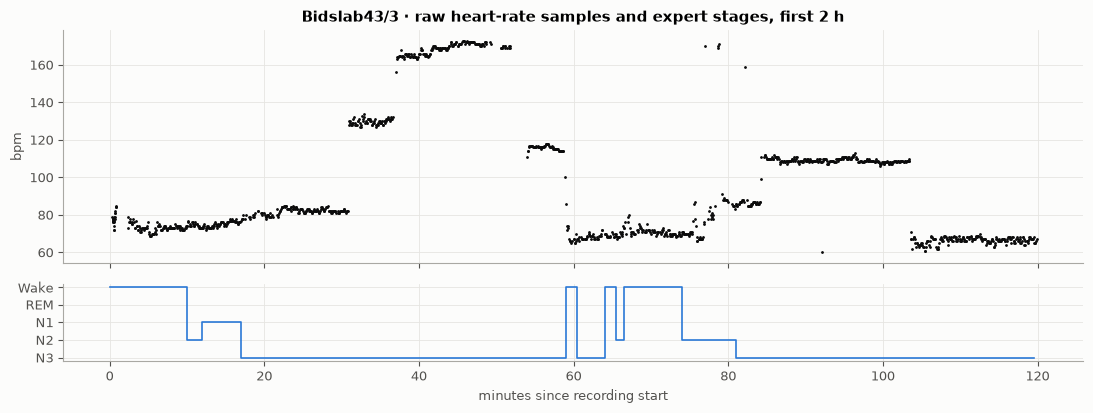

In [11]:
from sleepwatch.data.loader import load_night

raw = load_night(settings.raw_dir, "Bidslab43", 3)
minutes = (raw.hr["t"] - raw.rec_start) / 60
early = minutes < 120
steps = raw.hr.assign(minute=minutes, step=raw.hr["hr"].diff(), gap_s=raw.hr["t"].diff())
jumps = steps[early & (steps["step"].abs() >= 40) & (steps["gap_s"] <= 30)]
print(f"sample-to-sample jumps of 40 bpm or more within 30 s, first 2 h: {len(jumps)}")
display(jumps[["minute", "hr", "step", "gap_s"]].round(1))

fig, (ax_hr, ax_stage) = plt.subplots(
    2, 1, figsize=(11, 4.2), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
ax_hr.plot(minutes[early], raw.hr["hr"][early], ".", ms=2, color="#0b0b0b")
ax_hr.set(ylabel="bpm", title="Bidslab43/3 · raw heart-rate samples and expert stages, first 2 h")
height = np.array([4, 2, 1, 0, 3, np.nan])[raw.expert]  # Wake, N1, N2, N3, REM, unknown
epoch_min = np.arange(len(height)) * EPOCH_S / 60
keep = epoch_min < 120
ax_stage.step(epoch_min[keep], height[keep], where="post", color="#2a78d6")
ax_stage.set_yticks([4, 3, 2, 1, 0], ["Wake", "REM", "N1", "N2", "N3"])
ax_stage.set(xlabel="minutes since recording start")
plt.tight_layout()
plt.show()

## 8 · Findings

**Setup.** 157 test nights from 47 people, each with at least 2 earlier usable nights. Each
night has a clean version and up to 15 injected ones, 2,337 injected in total. `Bidslab31/3`,
`Bidslab31/5` and `Bidslab45/3` have no wake stretch to copy from, so they get only the HR
injections. All 157 rebuilt clean nights match the stored features and stages.

1. **The false-alarm calibration carries over to new people.** The primary detector flags 3.2%
   [0.7, 6.1] of clean test nights (5 of 157). The training null rates were 2.5–4.8%, and all six
   detectors stay between 2.5% and 4.5%.
2. **At that rate, only large, long changes are caught, and only some of the time** (primary
   detector):
   - +10 bpm over the whole sleep period: 27% [18, 37];
   - 8 inserted 3-min awakenings: 20% [13, 28];
   - sleep onset delayed by 60 min: 10% [5, 17];
   - everything smaller or shorter: 3–8%, close to the false-alarm rate. For 30-min and +3 bpm
     changes, recall is indistinguishable from it.

   At an assumed 10% of nights being anomalous, precision is at most 0.49. The scores do respond:
   AUROC rises with size and duration, to 0.82 (whole-night +10 bpm), 0.79 (8 awakenings) and
   0.91 (+60 min onset). The gap between AUROC and recall comes from where the threshold sits.
3. **Why recall is low** (post hoc, section 7):
   - **The threshold sits at the edge of the training nights.** To be flagged, a test night must
     beat all, or all but one, of about 125 training nights in at least one channel. This follows
     from four channels plus tail probabilities that move in steps of 1/(n+1).
   - **The largest injections move their channel by about 2–3 z** (median: 2.2 for whole-night
     +10 bpm, 2.5 for 8 awakenings, 3.0 for +60 min). That reaches the training nights' 95th
     percentile (1.6–3.0) but falls short of their maxima (3.1–5.9).
   - **The edge includes data problems.** At least one training night, `Bidslab43/3`, contains
     a stretch that looks like a measurement artifact, and it sets the `hr_window` edge in three
     of its four training folds.
4. **The personal baseline only helps where people differ in level.** Against a population-only
   baseline with the same stages and calibration:
   - whole-night +10 bpm: recall +0.17 [0.11, 0.24] and AUROC 0.82 vs 0.70;
   - 2-h +10 bpm: +0.03 [0.01, 0.05];
   - every other condition: the CI includes 0.

   This matches the expectation that a whole-night shift looks like a between-person difference
   to a population model.
5. **Staging is the bottleneck for fragmentation, and adds nothing for heart rate.**
   - **Fragmentation:** with expert stages, 8 awakenings are caught 63% of the time, against 20%
     with GRU stages (difference −0.43 [−0.53, −0.33]). The GRU shows a wake bout over only 57%
     of the inserted awakenings.
   - **Heart rate:** GRU and expert stages perform about the same. The stage-free detector
     catches more whole-night +10 bpm nights (36% vs 27%, GRU minus stage-free −0.09
     [−0.15, −0.03]). But its false-alarm rate is also higher (4.5% vs 3.2%) and its AUROC is
     similar (0.84 vs 0.82), so most of the gap is the operating point, not better separation.
6. **Baseline length:** no clear pattern by number of earlier nights (2, 3 or 4+). This is
   descriptive only, since the groups are different people.
7. **Real flagged nights:** 5 of 157, about what chance alone would produce. They are described,
   not explained:
   - **`Bidslab11/3` and `Bidslab66/3`:** HR above the personal band for most of the night. The
     highest 30-min windows are about 19–20 bpm above expectation, early in the night. Each person
     had only 2 earlier nights.
   - **`Bidslab22/6`:** HR climbs over the first ~1.5 h to about 18 bpm above expectation, then
     returns to the band after about 4 h.
   - **`Bidslab32/6`:** onset latency of 108 min, against this person's 5 earlier nights.
   - **`Bidslab43/3`:** a 30-min window 34 bpm above expectation. The raw samples look like a
     measurement artifact (section 7), but the summary doesn't say so.

**What this means for Phase 4.** All five summaries validate against the schema, so the
interface works. Two limits carry over:
- **Flags are rare and conservative.** A missing flag says little about whether a night was
  normal.
- **The data-quality field misses implausible heart rate.** An artifact can reach the agent
  looking like a real change in the person's night.

**Limits.**
- **The injections are idealized.** HR offsets are additive with ramps, and the awakenings are
  copied from the same night's wake, so real anomalies may look different.
- **Small calibration sets.** Each fold's null comes from about 37 people.
- **Precision is conditional:** it rests on an assumed prevalence.
- **Scope of claims:** no causal or psychological claims, and no HRV.
